# Vector distance analysis

This notebook measures the average distance between vector pairs and plots the distances as histograms, so the distributions can be compared.

Every question has four Sentence-BERT vectors of 384 numbers each:
- **Q**: the question
- **H**: the human Reddit comment
- **A**: the AI's own answer to the question (Qwen2.5-1.5B)
- **P**: the AI's paraphrase of the human comment

Distance is **cosine distance**, which is 1 minus the cosine similarity. A value of 0 means the two vectors point the same way, about 1 means they are unrelated, and 2 means they point in opposite directions. It is measured in the three vector setups from `data_dl.ipynb`:
1. `SBERT(response)` from `train_set.pkl` and `test_set.pkl`
2. `SBERT(question + response)` from `concat_train_set.pkl` and `concat_test_set.pkl`
3. `SBERT(question + response) − SBERT(question)`, the difference vectors

**Random baseline:** each vector is also compared with the same kind of vector from a *different* question. A pair type only carries a real signal if its distances are clearly smaller than the random ones.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Works whether the notebook runs from data/ or from the repo root
HERE = Path.cwd()
DATA = HERE if (HERE / "train_set.pkl").exists() else HERE / "data"

def load(name):
    with open(DATA / name, "rb") as file:
        return pd.DataFrame(pickle.load(file))

# Train and test are combined because no model is trained here
response = pd.concat([load("train_set.pkl"), load("test_set.pkl")], ignore_index=True)
concat = pd.concat([load("concat_train_set.pkl"), load("concat_test_set.pkl")], ignore_index=True)
assert (response.question == concat.question).all()
print(len(response), "questions")

# Colour-blind-safe series colours; grey is the random baseline
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a"]
BASELINE = "#898781"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "font.size": 10,
})

1898 questions


## Build the three vector setups

In [2]:
def stack(df, column):
    return np.stack(df[column].to_numpy()).astype(np.float32)

KINDS = {"Q": "question_bert", "H": "hr_bert", "A": "ar_bert", "P": "as_bert"}

setups = {
    "SBERT(response)": {k: stack(response, col) for k, col in KINDS.items()},
    "SBERT(question + response)": {k: stack(concat, col) for k, col in KINDS.items()},
}

# Difference vectors: subtracting the question removes it, so only H, A and P remain
q = setups["SBERT(question + response)"]["Q"]
setups["SBERT(q + r) − SBERT(q)"] = {k: setups["SBERT(question + response)"][k] - q for k in "HAP"}

## Distances

For the random baseline, every row is paired with the row a fixed random offset away. This guarantees no question is ever paired with itself. **Closer than random** is the share of questions whose real pair is closer than their random pair.

In [3]:
def cosine_distance(a, b):
    a = a / np.linalg.norm(a, axis=1, keepdims=True)
    b = b / np.linalg.norm(b, axis=1, keepdims=True)
    return 1.0 - (a * b).sum(axis=1)

n = len(response)
shift = int(np.random.default_rng(0).integers(1, n))  # never 0
other = (np.arange(n) + shift) % n                    # a different question for every row

PAIRS = {
    "Response pairs": [("H", "A", "human ↔ AI answer"),
                       ("H", "P", "human ↔ AI paraphrase"),
                       ("A", "P", "AI answer ↔ AI paraphrase")],
    "Question pairs": [("Q", "H", "question ↔ human"),
                       ("Q", "A", "question ↔ AI answer"),
                       ("Q", "P", "question ↔ AI paraphrase")],
}

rows, dist = [], {}
for setup, vec in setups.items():
    for group, pairs in PAIRS.items():
        for a, b, label in pairs:
            if a not in vec or b not in vec:
                continue
            paired = cosine_distance(vec[a], vec[b])
            random = cosine_distance(vec[a], vec[b][other])
            dist[(setup, group, label)] = (paired, random)
            rows.append({
                "setup": setup, "pair": label,
                "mean": round(float(paired.mean()), 3),
                "median": round(float(np.median(paired)), 3),
                "std": round(float(paired.std()), 3),
                "random mean": round(float(random.mean()), 3),
                "closer than random (%)": round(100 * float((paired < random).mean()), 1),
            })

summary = pd.DataFrame(rows).set_index(["setup", "pair"])
summary

mean  median    std  \
setup                      pair                                              
SBERT(response)            human ↔ AI answer          0.811   0.833  0.168   
                           human ↔ AI paraphrase      0.525   0.501  0.235   
                           AI answer ↔ AI paraphrase  0.601   0.601  0.216   
                           question ↔ human           0.759   0.780  0.162   
                           question ↔ AI answer       0.530   0.492  0.188   
                           question ↔ AI paraphrase   0.570   0.559  0.197   
SBERT(question + response) human ↔ AI answer          0.309   0.292  0.121   
                           human ↔ AI paraphrase      0.140   0.119  0.092   
                           AI answer ↔ AI paraphrase  0.264   0.244  0.116   
                           question ↔ human           0.140   0.123  0.095   
                           question ↔ AI answer       0.238   0.225  0.092   
                           question ↔ AI paraphrase   0.156   0.133  0.094   
SBERT(q + r) − SBERT(q)    human ↔ AI answer          0.602   0.605  0.164   
                           human ↔ AI paraphrase      0.412   0.376  0.229   
                           AI answer ↔ AI paraphrase  0.443   0.436  0.151   

                                                      random mean  \
setup                      pair                                     
SBERT(response)            human ↔ AI answer                0.943   
                           human ↔ AI paraphrase            0.938   
                           AI answer ↔ AI paraphrase        0.901   
                           question ↔ human                 0.914   
                           question ↔ AI answer             0.912   
                           question ↔ AI paraphrase         0.922   
SBERT(question + response) human ↔ AI answer                0.841   
                           human ↔ AI paraphrase            0.809   
                           AI answer ↔ AI paraphrase        0.837   
                           question ↔ human                 0.769   
                           question ↔ AI answer             0.830   
                           question ↔ AI paraphrase         0.796   
SBERT(q + r) − SBERT(q)    human ↔ AI answer                0.886   
                           human ↔ AI paraphrase            0.893   
                           AI answer ↔ AI paraphrase        0.801   

                                                      closer than random (%)  
setup                      pair                                               
SBERT(response)            human ↔ AI answer                            75.8  
                           human ↔ AI paraphrase                        94.3  
                           AI answer ↔ AI paraphrase                    87.2  
                           question ↔ human                             79.0  
                           question ↔ AI answer                         94.5  
                           question ↔ AI paraphrase                     92.9  
SBERT(question + response) human ↔ AI answer                            99.8  
                           human ↔ AI paraphrase                       100.0  
                           AI answer ↔ AI paraphrase                    99.7  
                           question ↔ human                            100.0  
                           question ↔ AI answer                         99.8  
                           question ↔ AI paraphrase                    100.0  
SBERT(q + r) − SBERT(q)    human ↔ AI answer                            97.6  
                           human ↔ AI paraphrase                        98.6  
                           AI answer ↔ AI paraphrase                    97.5

## Histograms

Each panel overlays three pair types (coloured lines) on the pooled random baseline (grey area). The difference vectors have no question pairs, so that panel is left empty.

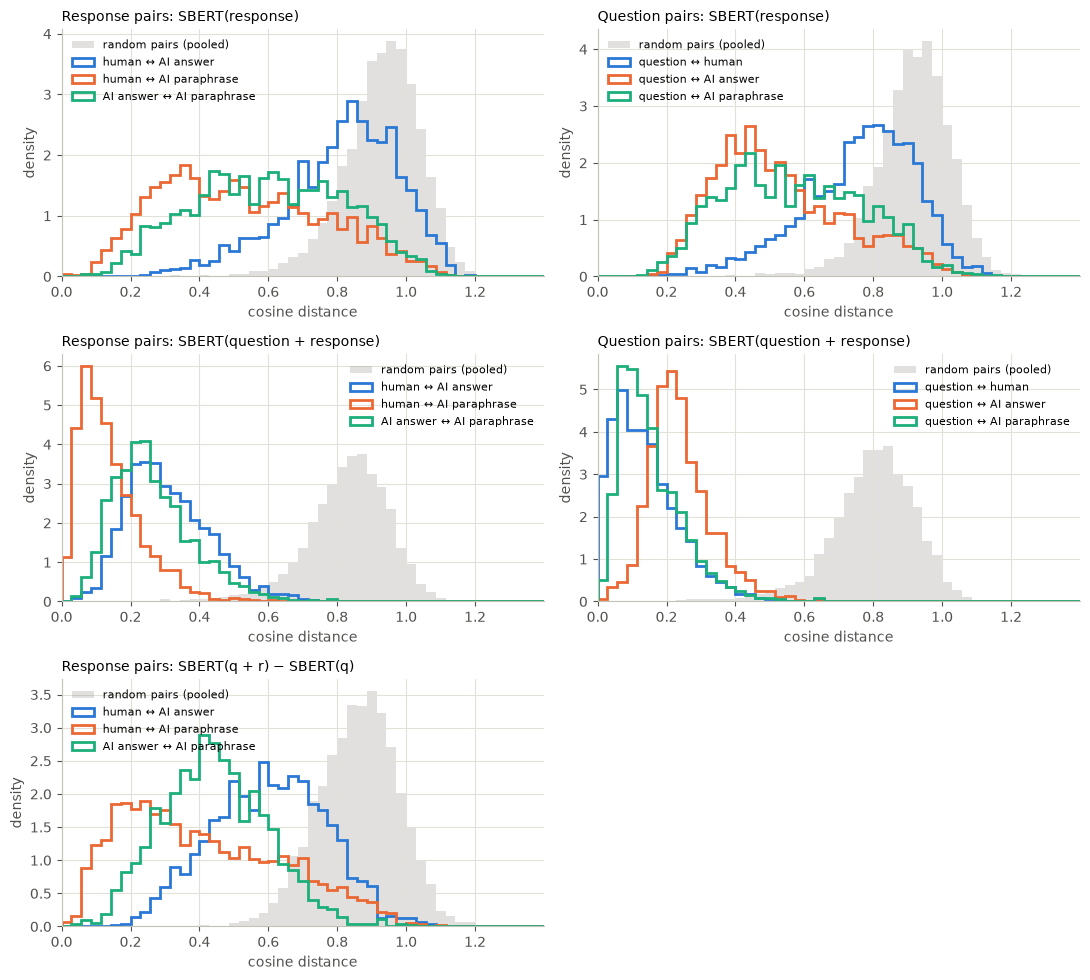

In [4]:
upper = np.ceil(max(np.max(v) for pair in dist.values() for v in pair) * 10) / 10
bins = np.linspace(0, upper, 50)
setup_names = list(setups)

fig, axes = plt.subplots(len(setup_names), 2, figsize=(11, 3.3 * len(setup_names)), squeeze=False)
for r, setup in enumerate(setup_names):
    for c, group in enumerate(PAIRS):
        ax = axes[r, c]
        keys = [k for k in dist if k[0] == setup and k[1] == group]
        if not keys:
            ax.set_visible(False)
            continue
        baseline = np.concatenate([dist[k][1] for k in keys])
        ax.hist(baseline, bins=bins, density=True, color=BASELINE, alpha=0.25,
                label="random pairs (pooled)")
        for colour, k in zip(COLOURS, keys):
            ax.hist(dist[k][0], bins=bins, density=True, histtype="step", linewidth=2,
                    color=colour, label=k[2])
        ax.set_xlim(0, upper)
        ax.set_title(f"{group}: {setup}", fontsize=10, loc="left")
        ax.set_xlabel("cosine distance")
        ax.set_ylabel("density")
        ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Observations (data as of 2026-10-09)

- **Every real pair is closer than a random pair.** In `SBERT(response)`, a human comment is closer to its own paraphrase than to a random paraphrase for 94% of questions, so the pairing information survives in the vectors.
- **Human ↔ AI paraphrase is the closest response pair in every setup**, with means of 0.53, 0.14 and 0.41. That fits "same content, different author", and supports using these pairs as the content anchor.
- **Human ↔ AI answer is the furthest real pair**, with a mean of 0.81, and it beats random for only 76% of questions. The AI's own answer often says something different, such as an "As an AI…" disclaimer.
- **AI answers stay close to the question (0.53) while human comments drift (0.76).** The AI tends to restate the question, while human comments are short (median 9 words) and often don't.
- **Adding the question squeezes everything together.** In `SBERT(question + response)`, every real pair falls to 0.14–0.31, because the shared question text dominates the vector. This supports the concern in `data_dl.ipynb`: the disentangler should take the response-only or difference vectors as input.
- **About 6% of paraphrases are no closer to their human comment than a random paraphrase** (the long right tail of the orange line). Some paraphrases lost the meaning, and about 40 in the training set are refusals. These are worth filtering out before the pairs are used for the content loss.

**Caveat:** the AI answer and paraphrase texts differ between the response-only files and the question + response files. Only 0.3% and 1.4% are identical, because each file regenerated them with random sampling. That means the A and P numbers aren't exactly comparable across setups. Generating the AI texts once and embedding them for each setup would fix this.